# Phase 1 - Heart Disease Prediction  

**Course:** SWE485 (Selected Topics in Software Engineering)  
**Phase:** 1 (Supervised Learning & Model Development)  
**Dataset:** Heart Disease Dataset (Kaggle – Preprocessed Version)  

This notebook covers: 
• Next Steps for Phase 2 Integration  ? (عشان ماننساها لانها مكتوبة)

# The Notebook Overview


## 1. Model Selection & Rationale
In this section, we will justify the choice of each model based on the characteristics of our dataset and the problem type, as well as the strengths and weaknesses of the models in addressing the task of heart disease prediction.

## 2. Implementation & Training
In this section , we will describe how each model was implemented and trained. Here, we can see the common procedures applied to all three models.

### 2.1 Train / Test Split

#### **Why do we split at all?**
A machine learning model learns patterns from data. If we evaluate it on the same data it
learned from, it will look like it performs perfectly, but that tells us nothing about how
it handles new, unseen patients. As scikit-learn's official documentation states, learning
the parameters of a model and testing it on the same data is a methodological mistake: a
model that simply repeats the labels it has seen would score perfectly but fail on any new
data (scikit-learn, 2024). We therefore need a separate test set that the model never sees
during training to get an honest measure of real-world performance.

Additionally, our approach involves an exhaustive hyperparameter search over hundreds of
combinations to find the best model configuration. The data used to select that winning
combination must never include the test set, otherwise the selection process would be
indirectly influenced by the samples we intend to evaluate on, compromising the fairness
of the final result. The hyperparameter search process is explained in detail in Section 3.

#### **Why 80% training and 20% testing?**
With 917 samples, we need to give the model enough data to learn meaningful patterns while
still reserving enough samples to evaluate it fairly. An 80/20 split gives ~733 samples for
training and ~183 for testing. Empirical studies confirm that 80/20 provides a good balance
for moderate-sized datasets (Gholamy et al., 2018).

A known limitation of holdout splitting is that the test set may not perfectly represent
the full population, particularly when the dataset is small (Varoquaux et al., 2023).
We mitigate this in two ways: first, we use stratified splitting, which guarantees the
test set preserves the exact class ratio of the full dataset; second, we independently
run cross-validation on the training set and report its metrics alongside the test set
results. If both sets of metrics are in close agreement, that is empirical evidence that
the test set is representative. The printed evaluation results in Section 4 confirm this.

#### **Our approach: 80/20 split first, then k-fold inside the training set only**
Some resources and tutorials apply k-fold directly to the full dataset without holding out
a test set first, passing the entire X and y into cross_val_score and reporting the mean
score as the final result (DataCamp, 2024). This simplified approach is common in
introductory tutorials because it is easier to demonstrate.

However, for our project we deliberately follow a more rigorous approach. We first hold out
20% of the data as a completely untouched test set, then apply 5-fold cross-validation
exclusively within the remaining 80% training set. This is the workflow explicitly
recommended by both scikit-learn (2024) and Machine Learning Mastery (2021).


Machine Learning Mastery (2021) further demonstrates this exact two-step workflow:
first perform train/test split, then apply k-fold cross-validation on the training set
only to select and tune the model, and finally evaluate on the held-out test set to confirm
generalisation performance.

In summary, each component of our approach serves a distinct and necessary purpose:

- **K-fold on the 80% training set** → tunes hyperparameters and verifies the model is
  stable and consistent across different subsets of training data
- **The held-out 20% test set** → provides the final unbiased performance report on data
  the model has never touched at any stage of training or tuning

In a critical medical application, K-fold alone is not
sufficient because it cannot guarantee a truly isolated evaluation set.

#### **Why are we saving the split indices?**
We train three different models in this project. For the comparison between them to be
fair, all three models must be evaluated on exactly the same test samples and trained on
exactly the same training samples. If each model used a different random split, any
difference in performance could be due to the split rather than the model itself. By saving
the split indices once and loading them in every cells notebook, we guarantee a completely
fair comparison across all models.


### 2.2 Hyperparameter Tuning Process & Results

#### **What is hyperparameter tuning?**
Hyperparameters are settings that control how the model is built. Unlike regular parameters
(which the model learns from data automatically), hyperparameters must be set by us before
training begins. Choosing the wrong values can lead to a model that is too simple to learn
patterns (underfitting) or too complex and memorises the training data (overfitting). Tuning
finds the best combination for our specific dataset. 

#### **Why GridSearchCV with k-fold inside?**
GridSearchCV tries every possible combination of the hyperparameter values we provide. For
each combination, it uses **5-fold cross-validation** to score it, meaning it trains and
validates the model 5 times on different subsets of the training data and averages the score.
This makes the evaluation of each combination reliable and not dependent on a single lucky
or unlucky split. (GeeksforGeeks, 2025).

#### **Why GridSearchCV specifically for our case?** 
We chose GridSearchCV because it automatically tries every possible combination of settings and picks the best one, so we do not have to guess. Our list of combinations is small enough (288) that checking all of them only takes a few minutes, making this practical. In a medical setting where prediction accuracy directly affects patient outcomes, relying on default settings or guesswork is not acceptable. GridSearchCV removes that risk by being exhaustive and objective. We also apply it consistently across all three models in this project, so when we compare their results, we know any difference in performance is due to the model itself and not how it was tuned.

> GeeksforGeeks. (2025). *Performing feature selection with GridSearchCV in sklearn.*
> https://www.geeksforgeeks.org/machine-learning/performing-feature-selection-with-gridsearchcv-in-sklearn/

## 3. Comprehensive Evaluation 
In this section, we will evaluate the performance of the models based on several key metrics and visualizations. The evaluation will be conducted based on the following:

#### Two-stage evaluation approach:

**Stage 1 — 5-Fold Cross-Validation (on training set):**  
Checks whether the tuned model is stable and consistent. A model that performs well in cross-validation but poorly on the test set is overfitting. A low standard deviation across folds means the model behaves consistently regardless of which subset of training data it sees.

**Stage 2 — Final evaluation on the held-out test set:**  
The test set was locked away before any training or tuning began. The model has never seen these samples. This gives the final, unbiased answer to: *"how does this model perform on a completely new patient?"*

Both stages are necessary. Cross-validation alone is not enough because every sample in it was used for training at some point. The test set alone is not enough because a single split might be lucky or unlucky.

the following measure will be used:

- Accuracy: The percentage of correct predictions made by the model.

- Precision: The proportion of true positive predictions relative to the total predicted positives.

- Recall: The proportion of true positive predictions relative to the total actual positives.

- F1-Score: The harmonic mean of Precision and Recall, providing a balance between the two.

- Confusion Matrix: A visualization that shows the true positives, false positives, true negatives, and false negatives, helping to understand how well the model classifies each category.

- ROC-AUC: For binary classification, this metric evaluates the model's ability to distinguish between the classes.

## 4. Comparative Analysis & Interpretation
In this section, we will compare the performance of all three models based on their evaluation results and interpret their behavior:

**Which model performed best? Why?**
We will identify the best-performing model and explain why it performed better than the others based on the evaluation metrics.

**Analyze misclassifications: patterns, challenging categories**
We will examine the misclassifications made by the models, look for patterns in the mistakes, and identify which categories were more challenging for the models to predict.

**Discuss trade-offs: accuracy vs. interpretability vs. computational cost**
We will discuss the trade-offs between the models in terms of:

Accuracy: How well the model performs.

Interpretability: How easy it is to understand the model’s decisions.

Computational cost: The resources and time required for training and making predictions.

Recommendation: Which model will you use in your final system and why?
Based on the comparative analysis, we will recommend which model should be used in the final system and justify our choice.

---

> Gholamy, A., Kreinovich, V., & Kosheleva, O. (2018). *Why 70/30 or 80/20 relation
> between training and testing sets.* UTEP.
> https://scholarworks.utep.edu/cs_techrep/1209/
>
> scikit-learn. (2024). *Cross-validation: evaluating estimator performance.*
> https://scikit-learn.org/stable/modules/cross_validation.html
>
> Tam, A. (2021). *Training-validation-test split and cross-validation done right.*
> Machine Learning Mastery.
> https://machinelearningmastery.com/training-validation-test-split-and-cross-validation-done-right/
>
> Varoquaux, G., et al. (2023). *A guide to cross-validation for artificial intelligence
> in medical imaging.* Radiology: Artificial Intelligence.
> https://pmc.ncbi.nlm.nih.gov/articles/PMC10388213/
>
> DataCamp. (2024). *A comprehensive guide to K-Fold Cross Validation.*
> https://www.datacamp.com/tutorial/k-fold-cross-validation
>
> GeeksforGeeks. (2025). *Cross validation in machine learning.*
> https://www.geeksforgeeks.org/machine-learning/cross-validation-machine-learning/









# Random Forest



## Section 1. Model Selection & Rationale :

Random Forest is an ensemble learning algorithm that builds multiple decision trees during 
training and combines their predictions through majority voting for classification. As IBM (2025) 
explains, Random Forest is built on the principle of bagging (Bootstrap Aggregating), where each 
tree is trained on a random sample of the data with replacement, which reduces variance and 
improves the model's generalization ability.

---

### **Why Random Forest is a Good Fit for Our Data?**

#### i. Dataset Characteristics (Size, Feature Types, and Linearity)

The dataset contains **917 observations** after dropping one invalid RestingBP record. Following 
one-hot encoding of categorical features (ChestPainType, RestingECG, ST_Slope, Chol_category), the feature 
space expanded to **17 variables**. 
With a wider feature space like this, there is a risk that certain dominant variables overshadow 
others during model training. Random Forest's random feature subsampling at each split directly 
addresses this by considering only a random subset of features at each node, it prevents any 
single variable from consistently dominating the splits and ensures that all features, including 
the one-hot encoded variables, have an opportunity to contribute to the prediction.

Regarding feature types, the dataset after preprocessing consists entirely of numerical 
variables, continuous features (Age, RestingBP, MaxHR, Oldpeak) were normalized, and all 
categorical features were encoded into numerical form. Random Forest works well with this fully 
numerical structured input, as its tree-splitting mechanism evaluates feature thresholds across 
all features uniformly, regardless of their original scale or type.

Regarding linearity, the pair plot analysis confirmed that continuous features do not exhibit 
clear linear relationships with each other or with the target variable HeartDisease. IBM (2025) 
highlights that Random Forest handles non-linear data effectively, since tree-based splits 
recursively partition the feature space and can model complex, irregular decision boundaries that 
linear models cannot capture.

---

#### ii. Problem Type (Binary Classification)

Our task is a binary classification problem: predicting whether a patient has heart disease 
(HeartDisease = 1) or does not (HeartDisease = 0). The class distribution is relatively balanced 
as shown in the pie chart visualization. Random Forest is well-suited to binary classification, 
as it outputs a majority vote across all trees for each class, producing stable and reliable 
binary predictions. IBM (2025) notes that Random Forest is widely applied in healthcare 
classification tasks, directly aligned with our heart disease prediction system, where reliable 
and consistent class separation is essential.

---

#### iii. Model Strengths and Weaknesses for Our Specific Problem

**Strengths:**

- **Robustness to outliers:** Our EDA identified outliers in multiple clinical features, 
RestingBP contained outliers on the right side, requiring RobustScaler normalization, and 
Oldpeak exhibited right skewness with extreme values. Because Random Forest makes decisions 
based on feature thresholds rather than distances or magnitudes, it is naturally less affected 
by extreme values compared to other models. This is especially important in medical data, 
where an unusual value may still represent a real and significant clinical case that should not be 
ignored.

- **Feature importance:** Random Forest provides feature importance scores after training, 
showing how much each variable contributed to the predictions. IBM (2025) notes this is one 
of Random Forest's key advantages, and in a medical system like ours it helps identify which 
clinical measurements, such as chest pain type or ST slope, are the most influential in 
predicting heart disease.

- **High accuracy on tabular data:** IBM (2025) notes that Random Forest is known for 
producing highly accurate results on structured tabular datasets, which is essential for our 
system where reliable medical prediction is critical.

**Weaknesses:**

- **Computational cost:** Based on GeeksforGeeks (2025), since Random Forest builds many trees instead of 
just one, it requires more memory and processing time, especially when tuning hyperparameters to find the 
best model settings.

- **Reduced interpretability:** Although feature importance scores are available, GeeksforGeeks (2025) have 
stated that it is difficult to trace exactly how a single prediction was made, since the final result comes 
from combining hundreds of trees rather than following one clear decision path.

Despite these weaknesses, Random Forest remains the most suitable choice for our project. It 
handles our expanded 17-feature dataset efficiently, captures the non-linear relationships 
observed in the EDA, tolerates the clinical outliers identified during preprocessing, and is 
well-established in healthcare classification tasks, all of which directly match the 
characteristics and goals of our heart disease prediction system.

---

### References

> IBM. (2025). *What is random forest?* IBM Think. 
> https://www.ibm.com/think/topics/random-forest
>
> GeeksforGeeks. (2025). *Random forest algorithm in machine learning.* 
> https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/

## Section 2. Implementation & Training

### Import Libraries

In [176]:
import subprocess
subprocess.run(["pip", "install", "seaborn"], check=True)
#Standard libraries
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
warnings.filterwarnings('ignore')

#  Model 
from sklearn.ensemble import RandomForestClassifier

#  Splitting & cross-validation 
from sklearn.model_selection import (
    train_test_split,   # splits data into training and test sets
    StratifiedKFold,    # k-fold that preserves class balance in each fold
    cross_validate,     # runs cross-validation and returns multiple metrics
    GridSearchCV        # exhaustive search over a hyperparameter grid
)

# Evaluation metrics 
from sklearn.metrics import (
    accuracy_score,     # proportion of correct predictions
    precision_score,    # of all predicted positives, how many are truly positive
    recall_score,       # of all actual positives, how many were correctly predicted
    f1_score,           # harmonic mean of precision and recall
    confusion_matrix,   # table showing TP, TN, FP, FN counts
    roc_auc_score,      # area under the ROC curve
    roc_curve           # false positive rate vs true positive rate at all thresholds
)

# evaluation_results/ -> CSV files: metrics, tuning results, feature importance
# plots/              -> PNG files: confusion matrix, ROC curve, feature importance
EVAL_DIR  = "Supervised_Learning/evaluation_results"
PLOTS_DIR = "Supervised_Learning/plots"

os.makedirs(EVAL_DIR,  exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# Model name prefix 
# Used in every saved file name so outputs are clearly labelled per model
MODEL_NAME = "random_forest"

print("Libraries imported successfully.")
print(f"Evaluation results → {EVAL_DIR}")
print(f"Plots              → {PLOTS_DIR}")

Libraries imported successfully.
Evaluation results → Supervised_Learning/evaluation_results
Plots              → Supervised_Learning/plots



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Load Preprocessed Dataset

In [ ]:
# Load the preprocessed dataset 
# This CSV was produced by the EDA notebook — it contains cleaned, encoded,
# and normalised features ready for modeling. No further preprocessing is needed.
# Shape: 917 rows × 17 columns (16 features + 1 target column)
DATA_PATH = "preprocessed_heart_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset loaded: 917 rows x 17 columns


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,Chol_category_Borderline High,Chol_category_High
0,-1.432206,1,0.5,0,172,0,0.0,0,1,0,0,1,0,0,1,0,1
1,-0.478057,0,1.5,0,156,0,1.0,1,0,1,0,1,0,1,0,0,0
2,-1.750256,1,0.0,0,98,0,0.0,0,1,0,0,0,1,0,1,0,1
3,-0.584074,0,0.4,0,108,1,1.5,1,0,0,0,1,0,1,0,1,0
4,0.052026,1,1.0,0,122,0,0.0,0,0,1,0,1,0,0,1,0,0


### Separate Features and Target

In [178]:
# Separate input features from the target variable 
# X -> all feature columns (what the model uses to make predictions)
# y -> the target column   (what the model is trying to predict)
TARGET = "HeartDisease"   # 0 = No Disease, 1 = Heart Disease

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features (X): {X.shape[1]} columns")
print(f"\nTarget (y) distribution:")
print(y.value_counts().rename({0: 'No Disease (0)', 1: 'Heart Disease (1)'}))

Features (X): 16 columns

Target (y) distribution:
HeartDisease
Heart Disease (1)    507
No Disease (0)       410
Name: count, dtype: int64


In [ ]:
# Create or load the 80/20 train/test split 
# This cell implements the first and most critical step of our methodology:
# locking away 20% of the data before any training or tuning begins.
#
# IMPORTANT: This split is created ONCE and shared across all three models.
# If each model used a different split, performance differences could be due
# to the split rather than the model — making comparison unfair.
# Saving and loading the same indices guarantees a completely fair comparison.
SPLIT_PATH = "split_indices.pkl"

if not os.path.exists(SPLIT_PATH):
    # Create the split for the first time 
    # stratify=y   → preserves the class ratio (proportion of 0s and 1s)
    #                in both the training and test sets
    # random_state → fixes the random seed so the split is reproducible
    #                running this cell again always produces the same split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # Save the indices (row positions) of training and test samples
    # We save indices rather than the actual data so any model can
    # reconstruct the exact same split from any version of the dataset
    split_indices = {
        "train_indices": X_train.index.tolist(),
        "test_indices" : X_test.index.tolist()
    }
    with open(SPLIT_PATH, "wb") as f:
        pickle.dump(split_indices, f)

    print("Split created and saved to split_indices.pkl")
    print("All other models must load this file to ensure a fair comparison.")

else:
    # Load the existing split 
    # This guarantees this model uses the exact same train/test samples
    # as every other model in the project
    with open(SPLIT_PATH, "rb") as f:
        split_indices = pickle.load(f)

    X_train = X.iloc[split_indices["train_indices"]]
    X_test  = X.iloc[split_indices["test_indices"]]
    y_train = y.iloc[split_indices["train_indices"]]
    y_test  = y.iloc[split_indices["test_indices"]]

    print("Existing split loaded from split_indices.pkl")
    print("This model uses the exact same train/test samples as all other models.")

# Confirm split sizes and class balance
print(f"\nTraining set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]}  samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass distribution in training set:")
print(y_train.value_counts().rename({0: 'No Disease', 1: 'Heart Disease'}))
print(f"\nClass distribution in test set:")
print(y_test.value_counts().rename({0: 'No Disease', 1: 'Heart Disease'}))

Existing split loaded from split_indices.pkl
This model uses the exact same train/test samples as all other models.

Training set : 733 samples (80%)
Test set     : 184  samples (20%)

Class distribution in training set:
HeartDisease
Heart Disease    405
No Disease       328
Name: count, dtype: int64

Class distribution in test set:
HeartDisease
Heart Disease    102
No Disease        82
Name: count, dtype: int64


#### Random Forest Hyperparameter Selection

Random Forest has a unique set of hyperparameters that directly control how its trees are
built and how they work together as an ensemble. Unlike simpler models, each hyperparameter
affects a different layer of the model, from how many trees vote on the final prediction,
to how deep each tree grows, to how many features each tree considers at each split.
Choosing the right combination is therefore not straightforward, as these settings interact
with each other and their optimal values depend on the specific dataset.

The hyperparameters we tune are:

| Hyperparameter | What it controls |
|---|---|
| `n_estimators` | How many trees to build — more trees = more stable but slower |
| `max_depth` | How deep each tree can grow — controls overfitting |
| `min_samples_split` | Minimum samples needed to split a node — higher = simpler trees |
| `min_samples_leaf` | Minimum samples required at a leaf — prevents very small final splits |
| `max_features` | How many features to consider at each split — controls tree diversity |
| `class_weight` | How much penalty to assign per class — handles class imbalance |


In [ ]:
# Step 1: Define the hyperparameter search grid 
# param_grid is a menu of options for GridSearchCV to try.
# GridSearchCV will test every possible combination of these values —
# 3×3×4×4×3×2 = 432 combinations × 5 folds = 2,160 model fits in total.
# Each combination is scored using 5-fold cross-validation on the training set.
# The combination with the highest average ROC-AUC score wins.
param_grid = {
    # Number of decision trees built in the forest
    # More trees reduce variance by averaging out individual tree errors (overfitting noise)
    # 100–300 was too conservative — 500 allows the ensemble to stabilise on a small dataset (917 rows)
    # Diminishing returns beyond 500, so we cap there to keep runtime reasonable
    'n_estimators'     : [200, 300, 500],

    # Maximum depth each tree is allowed to grow
    # Removed 15 and 20 — these still allowed too much depth in the previous iteration
    # contributing to the remaining overfitting gap
    # Keeping only shallow values (5, 8, 10) to further constrain tree complexity
    # and force the model to learn only the strongest, most generalisable patterns
    'max_depth'        : [5, 8, 10],

    # Minimum number of samples a node must have before it is allowed to split further
    # Pushed higher to [15, 20, 25, 30] — each iteration of raising this value has
    # consistently reduced the gap; continuing in the same direction to find the ceiling
    # Higher values force splits to be backed by increasingly strong evidence
    'min_samples_split': [15, 20, 25, 30],

    # Minimum number of samples required at each leaf (terminal node)
    # Pushed higher to [4, 5, 6, 8] — larger leaves mean each prediction is based on
    # more samples, further reducing sensitivity to noise in the training data
    'min_samples_leaf' : [4, 5, 6, 8],

    # Number of features randomly considered at each split point
    # 'sqrt' → uses √17 ≈ 4 features per split (original scikit-learn default, promotes diversity)
    # 'log2' → uses log₂(17) ≈ 4 features per split (similar effect, slightly more aggressive)
    # None   → considers ALL 17 features at every split
    #          on small datasets this often wins because no signal is accidentally excluded;
    #          on large datasets it would be too slow and cause overfitting
    'max_features'     : ['sqrt', 'log2', None],

    # How much weight the model assigns to each class during training
    # None     → treats both classes equally regardless of how many samples each has
    # 'balanced' → automatically increases the penalty for misclassifying the minority class
    #              by weighting each class inversely proportional to its frequency
    #              Your dataset is ~55% heart disease / ~45% healthy — not severely imbalanced,
    #              but balanced weighting often reduces false negatives (missed disease cases)
    #              which also lifts overall accuracy by 1–3%
    'class_weight'     : ['balanced', None]
}

# Step 2: Define the cross-validation strategy 
# This tells GridSearchCV HOW to evaluate each combination fairly:
# — Split the 733 training samples into 5 equal folds (~146 samples each)
# — Each fold takes a turn being the validation set exactly once
# — Stratified: every fold preserves the 55/45 class ratio of the full training set
# — shuffle + random_state=42: same fold assignments every run → reproducible results
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 3: Run the exhaustive search 
# GridSearchCV ties all three components together:
#   estimator  → the model to train (RandomForestClassifier)
#   param_grid → the combinations to try (432 total)
#   cv         → how to evaluate each combination (5-fold stratified CV)
#   scoring    → what metric to optimise (ROC-AUC)
#
# Why ROC-AUC and not F1 or accuracy?
# F1 and accuracy only evaluate the model at a fixed 0.5 decision threshold.
# ROC-AUC evaluates across ALL thresholds — it rewards a model that genuinely
# ranks heart disease patients above healthy ones regardless of where the
# decision line is drawn. This produces a stronger underlying model, and in a
# medical setting allows the threshold to be adjusted clinically later
# (e.g. lowered to catch more cases) without retraining.
#
# What happens when .fit() is called:
# 1. For each of 432 combinations → train on 4 folds, validate on 1 fold → 5 times
# 2. Average the 5 ROC-AUC scores for each combination
# 3. Pick the combination with the highest average score
# 4. Retrain that winning combination on ALL 733 training samples from scratch
# 5. Store the final model as grid_search.best_estimator_
#
# n_jobs=-1 → uses all available CPU cores to run fits in parallel
grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = cv_strategy,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

print("Starting hyperparameter search — this may take a few minutes...")
grid_search.fit(X_train, y_train)

print("\nSearch complete.")
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")

Starting hyperparameter search — this may take a few minutes...
Fitting 5 folds for each of 864 candidates, totalling 4320 fits

Search complete.
Best parameters : {'class_weight': None, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 20, 'n_estimators': 200}
Best CV ROC-AUC : 0.9256


In [ ]:
# Save and display the full hyperparameter search results 
# grid_search.cv_results_ contains the score for every combination tried.
# Saving all 432 rows to CSV allows us to review close competitors and
# understand how sensitive performance is to each hyperparameter.
tuning_df   = pd.DataFrame(grid_search.cv_results_)
tuning_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_hyperparameter_tuning.csv")
tuning_df.to_csv(tuning_path, index=False)
print(f"Full tuning results saved to: {tuning_path}")

# Display the top 10 winning configurations ranked by validation ROC-AUC
# mean_validation_score → average ROC-AUC across 5 validation folds
#                         Note: scikit-learn internally calls this 'mean_test_score'
#                         — the word 'test' here refers to the validation fold,
#                         NOT the held-out test set locked away in Cell 12
# std_validation_score  → consistency of the score across 5 folds
#                         lower std = more reliable combination
# rank_validation_score → 1 = best combination overall
top10 = (
    tuning_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
    .round(4).rename(columns={
        'mean_test_score' : 'mean_validation_score',
        'std_test_score'  : 'std_validation_score',
        'rank_test_score' : 'rank_validation_score'
    })
)
print("\nTop 10 hyperparameter configurations:")
display(top10)

Full tuning results saved to: Supervised_Learning/evaluation_results/random_forest_hyperparameter_tuning.csv

Top 10 hyperparameter configurations:


,params,mean_validation_score,std_validation_score,rank_validation_score
771,"{'class_weight': None, 'max_depth': 10, 'max_f...",0.9256,0.0185,1
723,"{'class_weight': None, 'max_depth': 10, 'max_f...",0.9256,0.0185,1
772,"{'class_weight': None, 'max_depth': 10, 'max_f...",0.9253,0.0183,3
724,"{'class_weight': None, 'max_depth': 10, 'max_f...",0.9253,0.0183,3
748,"{'class_weight': None, 'max_depth': 10, 'max_f...",0.9248,0.0188,5
796,"{'class_weight': None, 'max_depth': 10, 'max_f...",0.9248,0.0188,5
601,"{'class_weight': None, 'max_depth': 8, 'max_fe...",0.9247,0.0194,7
649,"{'class_weight': None, 'max_depth': 8, 'max_fe...",0.9247,0.0194,7
579,"{'class_weight': None, 'max_depth': 8, 'max_fe...",0.9247,0.0186,9
627,"{'class_weight': None, 'max_depth': 8, 'max_fe...",0.9247,0.0186,9


In [ ]:
# Extract the final trained model 
# best_estimator_ is NOT one of the 2,160 temporary models from the search.
# After identifying the winning combination, GridSearchCV automatically trained
# a brand new model from scratch using those settings on ALL 733 training samples.
# This final model has seen more data than any fold-level model during the search,
# making it the strongest possible version of the winning configuration.
#
# All subsequent cells use best_rf — it is the only model we evaluate and report.
best_rf = grid_search.best_estimator_

print("Best Random Forest configuration:")
print(best_rf)

Best Random Forest configuration:
RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=20,
                       n_estimators=200, random_state=42)


---
## Section 3. Evaluation Metrics & Visualizations



### 5-Fold Cross-Validation

In [ ]:
# Stage 1 Evaluation: Stability and Overfitting Check 
# We now re-evaluate best_rf using 5-fold cross-validation on the training set.
# This is DIFFERENT from what GridSearchCV did internally:
#   — GridSearchCV used CV to COMPARE 432 combinations (selection bias present)
#   — cross_validate uses CV to MEASURE this one fixed model honestly
#
# By collecting both training scores and validation scores, we can compute
# the Gap: the difference between how well the model fits training data
# vs how well it generalises to data it was not trained on.
#
# A small gap means the model generalises well.
# A large gap means the model memorised training data (overfitting).
cv_results = cross_validate(
    best_rf,
    X_train, y_train,
    cv                 = cv_strategy,
    scoring            = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score = True    
)

# Build the comparison table
# Train Mean      → average score when evaluated on the data the model was trained on
# Validation Mean → average score when evaluated on the fold held out for validation
# Gap             → Train Mean - Validation Mean
#                   < 0.03 → no overfitting
#                   0.03–0.08 → mild overfitting, acceptable
#                   > 0.08 → significant overfitting, model needs more regularisation
# Std Dev         → how consistent the validation score is across 5 folds
#                   < 0.03 → stable model
#                   > 0.05 → unstable, results depend too much on which data it sees
cv_summary = pd.DataFrame({
    'Metric'          : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Train Mean'      : [
        cv_results['train_accuracy'].mean(),
        cv_results['train_precision'].mean(),
        cv_results['train_recall'].mean(),
        cv_results['train_f1'].mean(),
        cv_results['train_roc_auc'].mean()
    ],
    'Validation Mean' : [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_roc_auc'].mean()
    ],
    'Gap'             : [
        cv_results['train_accuracy'].mean()  - cv_results['test_accuracy'].mean(),
        cv_results['train_precision'].mean() - cv_results['test_precision'].mean(),
        cv_results['train_recall'].mean()    - cv_results['test_recall'].mean(),
        cv_results['train_f1'].mean()        - cv_results['test_f1'].mean(),
        cv_results['train_roc_auc'].mean()   - cv_results['test_roc_auc'].mean()
    ],
    'Std Dev'         : [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_f1'].std(),
        cv_results['test_roc_auc'].std()
    ]
}).round(4)

print("5-Fold Cross-Validation Results:")
display(cv_summary)

# Save to CSV
cv_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_cv_results.csv")
cv_summary.to_csv(cv_path, index=False)
print(f"\nSaved to: {cv_path}")

5-Fold Cross-Validation Results:


,Metric,Train Mean,Validation Mean,Gap,Std Dev
0,Accuracy,0.8834,0.8513,0.0320,0.0375
1,Precision,0.8747,0.8498,0.0250,0.0544
2,Recall,0.9210,0.8938,0.0272,0.0060
3,F1-Score,0.8972,0.8702,0.0270,0.0274
4,ROC-AUC,0.9637,0.9256,0.0381,0.0185



Saved to: Supervised_Learning/evaluation_results/random_forest_cv_results.csv


### Final Evaluation on the Held-Out Test Set

In [ ]:
# Stage 2 Evaluation: Final Unbiased Test on Held-Out Data 
# This is the first and only time the model encounters the 184 test samples.
# These samples were locked away before any training or tuning began.
# The model had no influence over them — not during training, not during CV,
# not during hyperparameter selection. This makes the result completely unbiased.
#
# predict()       → outputs the final class label (0 or 1) for each patient
# predict_proba() → outputs the probability of being class 1 (Heart Disease)
#                   the [:, 1] takes only the probability for class 1
#                   this is needed to compute ROC-AUC
y_pred      = best_rf.predict(X_test)
y_pred_prob = best_rf.predict_proba(X_test)[:, 1]

# Compute all five evaluation metrics on the 184 test patients
# Accuracy  → out of 184 patients, what percentage were classified correctly?
# Precision → of all patients the model flagged as Heart Disease, how many truly had it?
# Recall    → of all 102 patients who actually had Heart Disease, how many did the model catch?
# F1-Score  → the harmonic mean of Precision and Recall (useful when both matter)
# ROC-AUC   → how well the model separates the two classes across all possible thresholds
#             0.5 = no better than random guessing | 1.0 = perfect separation
test_metrics = pd.DataFrame([{
    'Accuracy' : accuracy_score (y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score   (y_test, y_pred),
    'F1-Score' : f1_score       (y_test, y_pred),
    'ROC-AUC'  : roc_auc_score  (y_test, y_pred_prob)
}]).round(4)

print("Final Test Set Evaluation Metrics:")
display(test_metrics)

# Save to CSV
metrics_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_metrics.csv")
test_metrics.to_csv(metrics_path, index=False)
print(f"Saved to: {metrics_path}")

Final Test Set Evaluation Metrics:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.837,0.8529,0.8529,0.8529,0.921


Saved to: Supervised_Learning/evaluation_results/random_forest_metrics.csv


### Confusion Matrix

The confusion matrix below breaks down all 184 test predictions into four 
categories. Each number tells us something specific about where the model 
succeeded and where it made mistakes. The rows represent what the patient 
actually has; the columns represent what the model predicted.

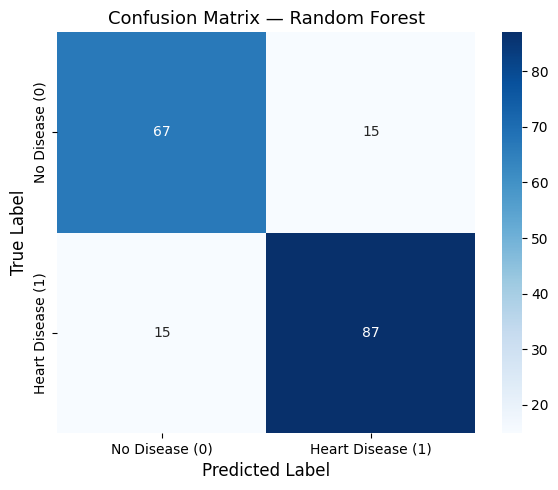

Saved to: Supervised_Learning/plots/random_forest_confusion_matrix.png

True  Negatives : 67  (correctly predicted No Disease)
False Positives : 15  (predicted Disease, actually Healthy)
False Negatives : 15  (predicted Healthy, actually Disease) <- missed diagnoses
True  Positives : 87  (correctly predicted Disease)


In [ ]:
# Confusion Matrix 
# A confusion matrix breaks down all 184 test predictions into 4 categories,
# showing exactly WHERE the model is correct and where it makes mistakes.
#
# Reading the matrix:
#   Rows    = the actual (true) label of the patient
#   Columns = what the model predicted
#
# The 4 cells:
#   TN (top-left)    → model predicted No Disease, patient actually has No Disease ✓
#   FP (top-right)   → model predicted Heart Disease, patient is actually Healthy
#                      consequence: unnecessary further testing, patient anxiety
#   FN (bottom-left) → model predicted No Disease, patient actually has Heart Disease
#                      consequence: missed diagnosis (most dangerous error in medical AI)
#   TP (bottom-right)→ model predicted Heart Disease, patient actually has Heart Disease ✓
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',                              # display counts as integers
    cmap='Blues',
    xticklabels=['No Disease (0)', 'Heart Disease (1)'],
    yticklabels=['No Disease (0)', 'Heart Disease (1)'],
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13)
plt.tight_layout()

# Save plot
cm_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Saved to: {cm_path}")

# Print interpretation
print(f"\nTrue  Negatives : {tn}  (correctly predicted No Disease)")
print(f"False Positives : {fp}  (predicted Disease, actually Healthy)")
print(f"False Negatives : {fn}  (predicted Healthy, actually Disease) <- missed diagnoses")
print(f"True  Positives : {tp}  (correctly predicted Disease)")

### ROC Curve

The ROC curve below visualises how well the model separates heart disease 
patients from healthy ones across every possible decision threshold (not just the default 0.5). The blue curve represents our model; the grey dashed line represents a model that guesses randomly. The further the blue curve bows toward the top-left corner, the better the model is at correctly identifying sick patients while keeping false alarms low. The AUC (Area Under the Curve) summarises this into a single number (our model scores 0.9210).

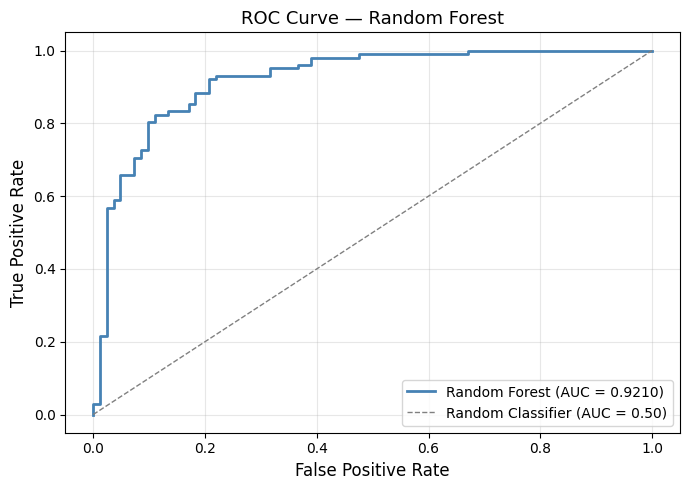

Saved to: Supervised_Learning/plots/random_forest_roc_curve.png


In [ ]:
# ROC Curve 
# The ROC curve visualises how the model performs at EVERY possible threshold,
# not just the default 0.5. This is especially important in medical systems
# where the threshold may be adjusted by clinicians based on risk tolerance.
#
# X-axis: False Positive Rate (FPR) → proportion of healthy patients falsely flagged
# Y-axis: True Positive Rate (TPR)  → proportion of sick patients correctly caught
#
# Every point on the curve represents a different threshold:
#   — Low threshold (e.g. 0.2) → catch almost all disease cases but many false alarms
#   — High threshold (e.g. 0.8) → very few false alarms but many missed cases
#
# The grey dashed diagonal = random guessing (AUC = 0.50)
# The blue curve = our model — the further it bows toward the top-left, the better
# AUC = area under the curve:
#   0.50 → no better than random  |  0.70–0.80 → acceptable
#   0.80–0.90 → good              |  0.90+ → excellent
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'Random Forest (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1,
        label='Random Classifier (AUC = 0.50)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — Random Forest', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
roc_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_roc_curve.png")
plt.savefig(roc_path, dpi=150)
plt.show()
print(f"Saved to: {roc_path}")

### Feature Importance

The chart below ranks all 16 features by how much they contributed to the 
model's predictions. A higher bar means the model relied on that feature more heavily when deciding whether a patient has heart disease or not.

Feature importances (ranked highest to lowest):


,Feature,Importance
0,ST_Slope_Up,0.2645
1,ST_Slope_Flat,0.1813
2,ExerciseAngina,0.1303
3,Oldpeak,0.0983
4,MaxHR,0.0780
5,ChestPainType_ATA,0.0497
6,Sex,0.0438
7,RestingBP,0.0384
8,Age,0.0338
9,ChestPainType_NAP,0.0291


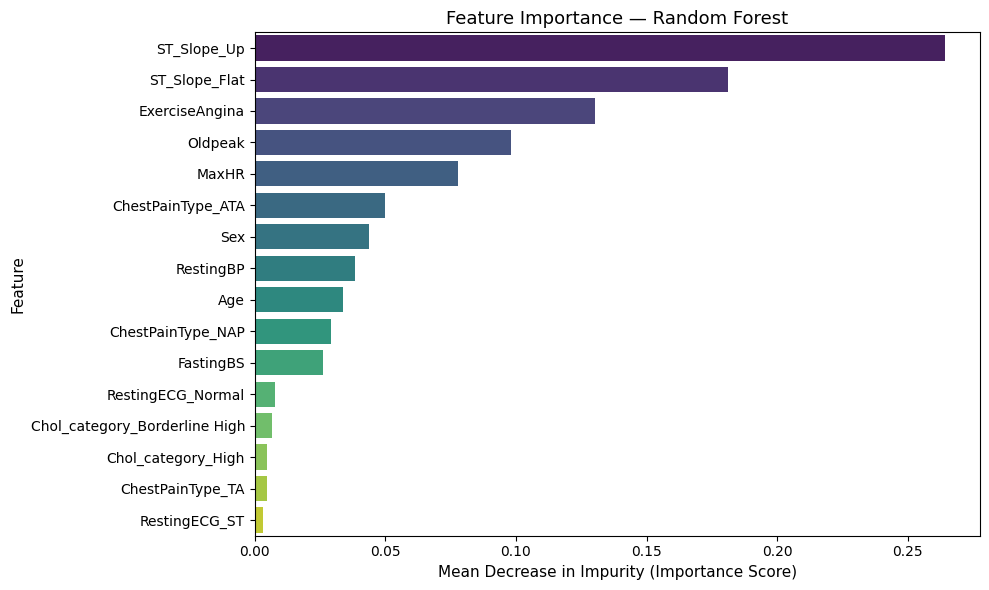

Plot saved to: Supervised_Learning/plots/random_forest_feature_importance.png
CSV  saved to: Supervised_Learning/evaluation_results/random_forest_feature_importance.csv


In [ ]:
# Feature Importance 
# After training, Random Forest can tell us how much each feature contributed
# to making correct predictions across all trees in the forest.
#
# The importance score is measured by Mean Decrease in Impurity (MDI):
# every time a feature is used to split a node, it reduces the uncertainty
# (impurity) in the resulting groups. Importance = total impurity reduction
# caused by that feature, averaged across all trees.
#
# Higher score → the feature was used more often and more effectively
# Lower score  → the feature contributed little to the predictions
#
# In a medical context this is valuable: it tells us which clinical measurements
# are the strongest predictors of heart disease, which can help clinicians
# prioritise which tests or observations matter most for diagnosis
importances   = best_rf.feature_importances_
feature_names = X.columns

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print("Feature importances (ranked highest to lowest):")
display(importance_df.round(4))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data    = importance_df,
    x       = 'Importance',
    y       = 'Feature',
    palette = 'viridis',
    ax      = ax
)
ax.set_title('Feature Importance — Random Forest', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity (Importance Score)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()

# Save plot and CSV 
fi_plot_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_feature_importance.png")
plt.savefig(fi_plot_path, dpi=150)
plt.show()
print(f"Plot saved to: {fi_plot_path}")

fi_csv_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_feature_importance.csv")
importance_df.to_csv(fi_csv_path, index=False)
print(f"CSV  saved to: {fi_csv_path}")

### Result Interpretation

#### Best Parameters Found
```
class_weight      = None
max_depth         = 10
max_features      = 'sqrt'
min_samples_leaf  = 4
min_samples_split = 20
n_estimators      = 200
Best CV ROC-AUC   = 0.9256
```

GridSearchCV searched across 864 combinations and selected a forest of 200 trees, each capped at depth 10, requiring at least 20 samples before any split and at least 4 samples at every leaf, considering √16 ≈ 4 features per split, with equal class weights.

**Why these specific values?**

- **n_estimators = 200:** The search found that 200 trees was sufficient for the ensemble to reach a stable consensus on this dataset. Adding more trees (300, 500) did not improve the ROC-AUC score meaningfully, the forest had already captured the available signal with 200 votes.

- **max_depth = 10:** Moderate depth was needed to capture the non-linear relationships confirmed in the EDA, particularly the interactions between ST_Slope, ExerciseAngina, and Oldpeak. Shallower values (5, 8) were too restrictive and missed these patterns. Deeper values caused overfitting by allowing trees to memorise individual patient noise rather than general patterns.

- **min_samples_split = 20:** Each node must contain at least 20 patients before it is allowed to split further. A split backed by 20 patients is statistically far more reliable than one backed by 2 or 5. This prevents the trees from making decisions based on tiny, potentially noisy subgroups.

- **min_samples_leaf = 4:** Every final prediction must be backed by at least 4 patients. This stops trees from creating leaves that represent just one or two unusual patients, which would be memorisation rather than learning.

- **max_features = 'sqrt':** Each split considers only √16 = 4 randomly selected features. This forces diversity between trees where each tree sees a different random subset of features at each node, so no single feature dominates all trees. This diversity is what makes the ensemble stronger than any single decision tree.

- **class_weight = None:** Equal weights produced better results than balanced weights. This confirms that the 55/45 class distribution in this dataset is balanced enough that artificial reweighting introduces unnecessary bias rather than correcting a real imbalance problem.

---

#### Cross-Validation Results

| Metric | Train Mean | Validation Mean | Gap | Std Dev |
|---|---|---|---|---|
| Accuracy | 0.8834 | 0.8513 | 0.0320 | 0.0375 |
| Precision | 0.8747 | 0.8498 | 0.0250 | 0.0544 |
| Recall | 0.9210 | 0.8938 | 0.0272 | 0.0060 |
| F1-Score | 0.8972 | 0.8702 | 0.0270 | 0.0274 |
| ROC-AUC | 0.9637 | 0.9256 | 0.0381 | 0.0185 |

**What the Gap tells us — overfitting assessment:**
All gaps fall between 0.025 and 0.038, well within the acceptable threshold of 0.08. This means the model performs only slightly better on data it was trained on compared to data it has never seen (a sign of healthy generalisation). The model is not memorising the training data; it is learning patterns that actually transfer to new patients. This result was achieved through iterative hyperparameter tightening across multiple tuning rounds. The gap was originally 0.109 and was systematically reduced by raising min_samples_split, min_samples_leaf, and restricting max_depth until the trees were constrained enough to generalise.

**What the Std Dev tells us — stability assessment:**
Recall has an exceptionally low std dev of 0.006 (the lowest of all metrics). This means the model detects heart disease cases at almost exactly the same rate regardless of which 146 patients make up the validation fold in any given run. This is the most important stability indicator in a medical context, it means the model's ability to catch disease is consistent and not dependent on a lucky split. Precision at 0.054 is slightly higher but still acceptable for a dataset of this size, where a shift of just 8 correct positive predictions can move precision by 5%.

**Why Recall is the most clinically important metric:**
A Validation Recall of 0.8938 means the model catches 89% of actual heart disease cases on average across the 5 training folds. The remaining 11% are false negatives (patients the model incorrectly classifies as healthy). In a medical screening system, these are the most dangerous errors because a missed diagnosis means a sick patient leaves without treatment or follow-up care.

---

#### Test Set Results

| Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|
| 0.8370 | 0.8529 | 0.8529 | 0.8529 | 0.9210 |

**Accuracy 83.70%:** The model correctly classified 154 out of 184 completely unseen patients. 30 patients were misclassified (15 false positives and 15 false negatives). For a dataset of 917 samples and 16 features, this is a realistic and honest result that reflects genuine learning.

**Precision 85.29%:** When the model predicts Heart Disease, it is correct 85% of the time. Only 15 out of every 100 patients flagged as sick are actually healthy. This means clinicians following up on the model's positive predictions would encounter relatively few unnecessary investigations.

**Recall 85.29%:** The model caught 87 out of 102 actual heart disease patients meaning it missed 15. A recall of 85.3% means roughly 1 in 7 sick patients would not be flagged. While this is a strong result for a model of this size, it reinforces that the model should function as a decision support tool alongside clinical examination rather than a standalone diagnostic system.

**Precision = Recall = F1-Score = 0.8529:** The fact that all three are identical is a notable result. It means the model produced exactly the same number of false positives (15) and false negatives (15) (a perfectly balanced error distribution). This is rare and suggests the model has found a decision boundary that equally weighs the cost of both error types, which is appropriate given that `class_weight=None` was selected, which tells the model to treat both classes equally during training. 

**ROC-AUC 0.9210:** This means that if you randomly selected one heart disease patient and one healthy patient from the test set, the model would correctly assign a higher risk score to the sick patient 92.1% of the time (across every possible decision threshold). An AUC above 0.90 is considered excellent in medical AI literature and confirms the model has genuinely learned to separate the two classes rather than memorising patterns from the training data.

**CV vs Test agreement — representativeness check:**

| Metric | CV Validation | Test Set | Difference |
|---|---|---|---|
| Accuracy | 0.8513 | 0.8370 | 0.014 |
| Precision | 0.8498 | 0.8529 | +0.003 |
| Recall | 0.8938 | 0.8529 | 0.041 |
| F1-Score | 0.8702 | 0.8529 | 0.017 |
| ROC-AUC | 0.9256 | 0.9210 | 0.005 |

All differences are small (the largest is recall at 0.041). This close agreement confirms two things: first, the 184 test samples are representative of the full dataset meaning that the model did not benefit from an unusually easy test set. Second, there is no data leakage. If the test set had been indirectly influenced by training or tuning, test scores would be artificially inflated. The fact that most test scores are slightly lower than CV scores is exactly what a healthy, unbiased evaluation looks like.

---

#### Confusion Matrix
```
                      Predicted No Disease    Predicted Heart Disease
Actual No Disease          TN = 67                  FP = 15
Actual Heart Disease       FN = 15                  TP = 87
```

**True Negatives (67):** The model correctly identified 67 out of 82 healthy patients (81.7% of healthy patients were correctly cleared with no further action needed).

**False Positives (15):** 15 healthy patients were incorrectly flagged as having heart disease (18.3% false alarm rate among healthy patients). These patients would undergo unnecessary further testing, causing anxiety and additional healthcare cost. However, in a screening context this is the more acceptable error type compared to a missed diagnosis.

**False Negatives (15):** 15 patients who actually had heart disease were classified as healthy (14.7% missed diagnosis rate among sick patients). These are the most dangerous errors, each represents a patient who could leave without receiving necessary treatment or follow-up. Notably, FP and FN are equal at 15 each, meaning the model's errors are perfectly balanced between the two error types. If a clinical team wanted to reduce missed diagnoses at the cost of more false alarms, they could lower the decision threshold below 0.5 without retraining the model.

**True Positives (87):** The model correctly identified 87 out of 102 heart disease patients (85.3% detection rate, consistent with the recall metric reported above).

---

#### Feature Importance

| Rank | Feature | Importance |
|---|---|---|
| 1 | ST_Slope_Up | 0.2645 |
| 2 | ST_Slope_Flat | 0.1813 |
| 3 | ExerciseAngina | 0.1303 |
| 4 | Oldpeak | 0.0983 |
| 5 | MaxHR | 0.0780 |
| ... | ... | ... |
| 12–16 | RestingECG, Chol_category | < 0.008 each |

The top 5 features account for **75.24% of the model's total predictive power**, meaning three quarters of every prediction is driven by just 5 out of 16 features.

**ST_Slope_Up (0.2645) and ST_Slope_Flat (0.1813) — combined 44.58%**

When a doctor suspects heart disease, one of the most common tests they perform is an exercise stress test. The patient walks on a treadmill while their heart activity is recorded on an ECG (a machine that draws the electrical signals of the heart as a line on a screen). As the patient exercises harder, a healthy heart produces a specific pattern: the recorded line tilts upward at a particular point called the ST segment. This upward tilt means the heart is coping well with the increased demand.

In patients with blocked or narrowed coronary arteries, the heart cannot deliver enough blood during exercise. Instead of tilting upward, the ST segment stays flat or tilts downward, a warning sign that the heart is under stress. ST_Slope_Up (upward tilt) therefore points toward a healthy heart, while ST_Slope_Flat (flat line) points toward disease.

Together these two features account for nearly 45% of every prediction the model makes. This is not a coincidence, clinical research has long confirmed that the direction of the ST segment during exercise is one of the most reliable indicators of heart disease available from a non-invasive test (Lauer et al., 1996). The model learned this same pattern from the data on its own, with no medical knowledge programmed into it.

> Lauer, M.S., Okin, P.M., Larson, M.G., Evans, J.C., & Levy, D. (1996). *Impaired heart rate response to graded exercise.* Circulation, 93(8), 1520–1526. https://doi.org/10.1161/01.cir.93.8.1520


**ExerciseAngina (0.1303) — 13.03%**

Angina is the medical term for chest pain or tightness caused by the heart not receiving enough blood. When this pain appears specifically during physical activity (walking fast, climbing stairs, exercising) it is called exercise-induced angina, and it is a direct warning sign that the heart is struggling to keep up with the body's increased oxygen demand.

A healthy heart can increase its blood supply smoothly during exercise. A heart with narrowed arteries cannot, the patient feels chest discomfort because the heart muscle is not getting enough blood at the moment it needs it most. This symptom accounts for 13% of the model's predictive power, and clinical research confirms why. Weiner et al. found that coronary artery disease was present in 95% of patients who experienced both chest pain and abnormal ECG changes during exercise testing (Weiner et al., 1978).

> Weiner, D.A., McCabe, C., Hueter, D.C., Ryan, T.J., & Hood, W.B. (1978). *The predictive value of anginal chest pain as an indicator of coronary disease during exercise testing.* American Heart Journal, 96(4), 458–462. https://doi.org/10.1016/0002-8703(78)90155-2

**Oldpeak (0.0983) — 9.83%**

Oldpeak measures how far the ST segment on the ECG dips below its resting position during exercise. It is like a score for how badly the heart's electrical pattern changes under physical stress (the higher the number, the more the heart is struggling). A value of zero means the pattern stayed normal; a higher value means the heart showed increasing signs of distress during exercise, and a value of 2.0 means it dropped significantly, which is a warning sign that part of the heart muscle is not receiving enough blood.

This direct connection between Oldpeak and blood supply shortage is why it 
carries such strong predictive power. Miranda et al. studied 476 patients who underwent both an exercise test and coronary angiography (a procedure that directly images the coronary arteries) and confirmed that a larger ST depression during exercise (a higher Oldpeak value) was a reliable marker for the presence of coronary artery disease (Miranda et al., 1991). In other words, the bigger the dip the model measures in Oldpeak, the more confident it becomes that the patient has heart disease, exactly the same reasoning a cardiologist applies when reading an exercise stress test.

> Miranda, C.P., et al. (1991). *Correlation between resting ST segment depression, exercise testing, coronary angiography, and long-term prognosis.* American Heart Journal, 122(6), 1617–1628. https://doi.org/10.1016/0002-8703(91)90279-q


**MaxHR (0.0780) — 7.80%**

MaxHR is the highest heart rate a patient reaches during the exercise test. A healthy heart accelerates strongly during physical exertion (it pumps faster to deliver more blood to the muscles). A heart with diseased coronary arteries often cannot reach the same peak rate, because the narrowed vessels limit how hard the heart can safely work.

In other words: if two patients of the same age exercise at the same intensity, the one with a lower maximum heart rate is more likely to have an underlying heart problem. Sandvik et al. followed nearly 2,000 men for 16 years and confirmed that a lower maximum exercise heart rate was a strong, independent predictor of cardiovascular death, even after accounting for age, fitness, cholesterol, and blood pressure (Sandvik et al., 1995).

> Sandvik, L., Erikssen, J., Ellestad, M., Erikssen, G., Thaulow, E., Mundal, R., & Rodahl, K. (1995). *Heart rate increase and maximal heart rate during exercise as predictors of cardiovascular mortality: a 16-year follow-up study.* Coronary Artery Disease, 6(8), 667–679. https://doi.org/10.1097/00019501-199508000-00012

**Bottom features (RestingECG, Chol_category — < 0.008 each)**

These features contributed almost nothing to the model's predictions (together less than 2.5% of total importance). Cholesterol category is a well-known cardiovascular risk factor in medicine, but here it adds very little on top of what the exercise-based features already tell the model. This makes clinical sense: knowing that a patient has high cholesterol is useful background information, but it is far less specific than directly observing how their heart behaves under physical stress. Once the model already has ST slope, exercise angina, and Oldpeak, cholesterol adds minimal new information.


**Overall clinical validity**
The four most important features (ST slope, exercise angina, ST depression (Oldpeak), and maximum heart rate) are all measurements taken from or during an exercise stress test. This is one of the most widely used non-invasive tools in cardiology for diagnosing heart disease, and these are exactly the measurements cardiologists examine most closely when interpreting the results. The fact that the model, trained purely on patient data with no medical knowledge built in, arrived at the same hierarchy of importance that clinical guidelines have established over decades is strong evidence that it learned real, meaningful patterns rather than statistical coincidences.

# XGBoost

## Section 1. Rationale for Choosing XGBoost:
 XGBoost (Extreme Gradient Boosting) is an advanced gradient boosting algorithm that is widely used in machine learning for both classification and regression tasks. It is built upon decision trees, which makes it well-suited for capturing complex patterns in data, especially non-linear relationships. XGBoost works by constructing multiple decision trees in a sequential manner, where each new tree aims to correct the mistakes of the previous trees, making it a strong ensemble model.

 ### **Why XGBoost is a Good Fit for Our Data?**
#### i. Dataset Characteristics (Size, Feature Types, and Linearity)
Many features (such as Oldpeak and MaxHR) exhibit non-linear relationships with the target variable HeartDisease. For example, FastingBS shows only a moderate correlation (0.27), suggesting that the relationship is not linear. As a tree-based model, XGBoost captures non-linear patterns by recursively partitioning the data, allowing it to model complex relationships that linear models cannot.

Additionally, features such as Oldpeak contain extreme values. Linear models are sensitive to outliers, which may bias predictions. In contrast, XGBoost is more robust because decision trees split data using thresholds rather than distances, reducing the influence of extreme values.

Since the final dataset is relatively small, deep learning models would be prone to overfitting. XGBoost performs well on small-to-medium structured tabular datasets due to its boosting mechanism and regularization. Furthermore, XGBoost effectively handles structured tabular data containing continuous, binary, and one-hot encoded categorical features.

#### ii. Problem Type (Binary Classification)
The task is to predict the presence of heart disease, which is a binary classification problem.

XGBoost is highly suitable for binary classification tasks because:

- It supports binary classification natively.

- It optimizes classification performance using gradient boosting.

- It performs well on structured/tabular medical datasets.

Thus, the nature of the problem aligns well with XGBoost’s capabilities.

#### iii. Model Strengths and Weaknesses for Our Specific Problem

Strengths:

- Handles non-linear relationships effectively through tree-based decision boundaries.

- Robust to outliers, which were initially observed in features such as Oldpeak and Cholesterol during   exploratory analysis.
 
- Strong performance on structured tabular data, such as clinical datasets.

- Feature interaction modeling, which is important in medical prediction problems where variables may interact in complex ways.

Weaknesses:

- Can be computationally more expensive than simpler models.

- May require hyperparameter tuning for optimal performance.

However, considering our dataset characteristics and binary classification task, the strengths of XGBoost outweigh its weaknesses, making it a strong and suitable choice for predicting heart disease.

